In [190]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F
import re

from pyspark.sql.functions import col, udf
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/15 07:01:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2025-11-01"

# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
print(dates_str_lst)

['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01']


In [4]:
# BRONZE
# create bronze datalake - lms
bronze_lms_directory = "datamart/bronze/lms/"

if not os.path.exists(bronze_lms_directory):
    os.makedirs(bronze_lms_directory)

# run bronze backfill - lms
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_lms_table(date_str, bronze_lms_directory, spark)



2023-01-01row count: 530


saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv


2023-02-01row count: 1031


saved to: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-03-01row count: 1537
saved to: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv
2023-04-01row count: 2047
saved to: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv
2023-05-01row count: 2568
saved to: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv
2023-06-01row count: 3085
saved to: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv
2023-07-01row count: 3556


saved to: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv
2023-08-01row count: 4037
saved to: datamart/bronze/lms/bronze_loan_daily_2023_08_01.csv
2023-09-01row count: 4491
saved to: datamart/bronze/lms/bronze_loan_daily_2023_09_01.csv
2023-10-01row count: 4978
saved to: datamart/bronze/lms/bronze_loan_daily_2023_10_01.csv
2023-11-01row count: 5469
saved to: datamart/bronze/lms/bronze_loan_daily_2023_11_01.csv
2023-12-01row count: 5428
saved to: datamart/bronze/lms/bronze_loan_daily_2023_12_01.csv
2024-01-01row count: 5412
saved to: datamart/bronze/lms/bronze_loan_daily_2024_01_01.csv
2024-02-01row count: 5424
saved to: datamart/bronze/lms/bronze_loan_daily_2024_02_01.csv
2024-03-01row count: 5425
saved to: datamart/bronze/lms/bronze_loan_daily_2024_03_01.csv
2024-04-01row count: 5417
saved to: datamart/bronze/lms/bronze_loan_daily_2024_04_01.csv
2024-05-01row count: 5391
saved to: datamart/bronze/lms/bronze_loan_daily_2024_05_01.csv
2024-06-01row count: 5418
saved to: datamart/br

NameError: name 'source' is not defined

In [12]:
# bronze - financials and attributes
table_dict = {
    'source': ['data/features_attributes.csv', 'data/features_financials.csv'],
    'directory': ['datamart/bronze/attributes/', 'datamart/bronze/financials/'],
    'filename': ['cust_attr', 'cust_fin']
             }

for i in range(len(table_dict['source'])):
    if not os.path.exists(table_dict['directory'][i]):
        os.makedirs(table_dict['directory'][i])
    utils.data_processing_bronze_table.process_bronze_other_tables(
        table_dict['source'][i], 
        table_dict['directory'][i], 
        table_dict['filename'][i], 
        spark
    )

features_attributes.csv has 12500 rows.
saved to:  datamart/bronze/attributes/bronze_cust_attr.csv
features_financials.csv has 12500 rows.
saved to:  datamart/bronze/financials/bronze_cust_fin.csv


In [14]:
import importlib
import utils.data_processing_bronze_table

importlib.reload(utils.data_processing_bronze_table)

# bronze - clickstream
bronze_clickstream_directory = "datamart/bronze/clickstream/"

if not os.path.exists(bronze_clickstream_directory):
    os.makedirs(bronze_clickstream_directory)

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"
dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
print(dates_str_lst)

for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_clickstream_table(
        date_str, 
        bronze_clickstream_directory, 
        spark
    )

['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01']
2023-01-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2023_01_01.csv
2023-02-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2023_02_01.csv
2023-03-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2023_03_01.csv
2023-04-01row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2023_04_01.csv
2023-05-01row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2023_05_01.csv
2023-06-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2023_06_01.csv
2023-07-01row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2023_07_01.csv


2023-08-01row count: 8974


...

saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2024_09_01.csv
2024-10-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2024_10_01.csv


2024-11-01row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2024_11_01.csv


2024-12-01row count: 8974


saved to: datamart/bronze/clickstream/bronze_clickstream_daily_2024_12_01.csv


# SILVER (working)

## EDA

In [3]:
clicks_df = spark.read.csv('data/feature_clickstream.csv', header = True, inferSchema = True)
attr_df = spark.read.csv('data/features_attributes.csv', header = True, inferSchema = True)
fin_df = spark.read.csv('data/features_financials.csv', header = True, inferSchema = True)

In [4]:
from pyspark.sql.functions import col, sum, isnan, when
def spark_info(df):
    print(f"Rows: {df.count()}, Columns: {len(df.columns)}")
    print(f"\nSchema:")
    df.printSchema()
    print(f"Null counts:")
    df.select([
        sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]).show()


### Features_attributes

In [7]:
spark_info(attr_df)

print(f'\nDescribe table:')
print(attr_df.describe().show())

Rows: 12500, Columns: 6

Schema:
root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

Null counts:
+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|  0|  0|         0|            0|
+-----------+----+---+---+----------+-------------+


Describe table:
+-------+-----------+------+------------------+-----------+----------+
|summary|Customer_ID|  Name|               Age|        SSN|Occupation|
+-------+-----------+------+------------------+-----------+----------+
|  count|      12500| 12500|             12500|      12500|     12500|
|   mean|       NULL|  NULL|104.40925566888646|       NULL|      NULL|
| stddev|       NULL|  NULL| 659.4794049008866|       NULL|      NULL|
|    min| 

In [10]:
from pyspark.sql.functions import countDistinct

attr_df.select(
    countDistinct("Customer_ID").alias("custID_uinque"),
    countDistinct("Occupation").alias("occu_unique"),
    countDistinct("SSN").alias("ssn_unique")
).show()

+-------------+-----------+----------+
|custID_uinque|occu_unique|ssn_unique|
+-------------+-----------+----------+
|        12500|         16|     11798|
+-------------+-----------+----------+



In [9]:
attr_df.groupBy("Occupation").count().orderBy("count", ascending = False).show()

+-------------+-----+
|   Occupation|count|
+-------------+-----+
|      _______|  880|
|       Lawyer|  828|
|    Architect|  795|
|     Engineer|  793|
|   Accountant|  791|
|    Scientist|  789|
|      Teacher|  782|
|Media_Manager|  780|
|    Developer|  780|
|     Mechanic|  780|
| Entrepreneur|  776|
|   Journalist|  761|
|       Doctor|  760|
|     Musician|  741|
|      Manager|  736|
|       Writer|  728|
+-------------+-----+



In [12]:
attr_df.groupBy("SSN").count().orderBy("count", ascending = False).show(5)

+-----------+-----+
|        SSN|count|
+-----------+-----+
|  #F%$D@*&8|  703|
|706-59-9144|    1|
|508-88-3060|    1|
|564-87-3414|    1|
|118-02-3131|    1|
+-----------+-----+
only showing top 5 rows



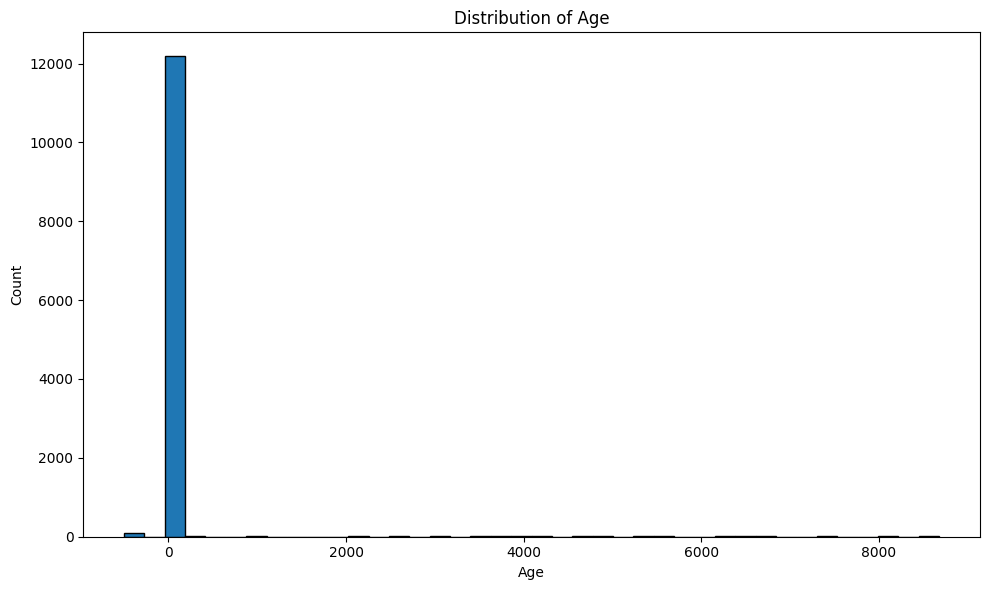

In [33]:
# Convert just the one column to pandas
age_pd = attr_df.select("Age").toPandas()

# convert datatype
age_pd["Age"] = age_pd["Age"].str.strip().str.replace("_", "").astype(int)


# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(age_pd["Age"], bins=40, edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [40]:
age_pd[age_pd['Age'] > 100].sort_values('Age')

,Age
8801,169
9154,203
7320,210
124,236
12379,305
...,...
11900,8623
12286,8628
11209,8663
676,8669


In [43]:
attr_df[attr_df['Occupation'] == '_______'].show()

+-----------+-----------------+-----+-----------+----------+-------------+
|Customer_ID|             Name|  Age|        SSN|Occupation|snapshot_date|
+-----------+-----------------+-----+-----------+----------+-------------+
| CUS_0x1044|    Maki Shirakip|   44|  #F%$D@*&8|   _______|   2023-06-01|
| CUS_0x104f|            Markm|   20|264-84-8069|   _______|   2024-10-01|
| CUS_0x1098|           Krudyz|   23|466-10-5742|   _______|   2025-01-01|
| CUS_0x10c5|            Moony|   24|041-74-6785|   _______|   2024-08-01|
| CUS_0x10e7|           Carewj|3843_|094-89-6380|   _______|   2024-11-01|
| CUS_0x10f9|Gilles Guillaumev|   54|746-79-6875|   _______|   2023-05-01|
| CUS_0x1130|       Elizabethr|   37|846-60-3664|   _______|   2023-07-01|
| CUS_0x1183|          Barlyna|   22|972-42-3182|   _______|   2024-04-01|
| CUS_0x1197|           Nayako|   28|799-23-8283|   _______|   2024-12-01|
| CUS_0x11b1|           Browne|   28|347-47-6952|   _______|   2023-05-01|
| CUS_0x11eb|        Mill

In [53]:
def process_silver_attr(bronze_directory, silver_directory, spark):
    # connect to bronze table
    filepath = bronze_directory
    df = spark.read.csv(filepath, header = True, inferSchema = True)


    # remove trailing "_" in age
    df = df.withColumn("Age", F.regexp_replace(col("Age"), "_$", ""))

    # enforce schema
    column_type_map = {
        "Customer_ID": StringType(),
        "Name": StringType(), 
        "Age": IntegerType(), 
        "SSN": StringType(), 
        "Occupation": StringType(),
        "snapshot_date": DateType()
    }

    for column, new_type in column_type_map.items():
        df = df.withColumn(column, col(column).cast(new_type))

    # replace invalid SSN with null
    df = df.withColumn(
        "SSN",
        F.when(col("SSN").rlike(r"^\d{3}-\d{2}-\d{4}$"), col("SSN")).otherwise(None)
    )

    # replace invalid age with null
    df = df.withColumn(
        "Age",
        F.when((col("Age") > 0) & (col("Age") <= 120), col("Age")).otherwise(None)
    ) 

    # replace invalid occupation with null
    df = df.withColumn(
        "Occupation",
        F.when(col("Occupation") == '_______', None).otherwise(col("Occupation"))
    )


    # # create directory path
    # if not os.path.exists(silver_directory):
    #     os.makedirs(silver_directory)
    
    # # save to datamart OR JOIN WITH FINANCIALS????
    # filepath = silver_directory + 'silver_cust_attr.csv'
    # df.toPandas().to_csv(filepath, index = False)
    # print("saved to: ", filepath)

    return df



In [54]:
temp = process_silver_attr('data/features_attributes.csv', 'datamart/silver/cust_attr/', spark)

In [56]:
spark_info(temp)

print(f'\nDescribe table:')
print(temp.describe().show())

Rows: 12500, Columns: 6

Schema:
root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

Null counts:
+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|319|703|       880|            0|
+-----------+----+---+---+----------+-------------+


Describe table:
+-------+-----------+------+------------------+-----------+----------+
|summary|Customer_ID|  Name|               Age|        SSN|Occupation|
+-------+-----------+------+------------------+-----------+----------+
|  count|      12500| 12500|             12181|      11797|     11620|
|   mean|       NULL|  NULL| 33.61907889335851|       NULL|      NULL|
| stddev|       NULL|  NULL|10.769332965307894|       NULL|      NULL|
|    min|

In [50]:
# temp = process_silver_attr(
#     'datamart/bronze/attributes/bronze_cust_attr.csv',
#     'datamart/silver/silver_cust_attr.csv', 
#     spark)

### Features_financials

In [57]:
spark_info(fin_df)

print(f'\nDescribe table:')
print(fin_df.describe().show())

Rows: 12500, Columns: 22

Schema:
root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: string (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: string (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: string (nullable = true)
 |-- Changed_Credit_Limit: string (nullable = true)
 |-- Num_Credit_Inquiries: double (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: string (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: string (nullable = true)
 |-- Payment_Behaviour: 

[Stage 83:>                                                         (0 + 1) / 1]

+-------+-----------+------------------+---------------------+------------------+------------------+------------------+-----------------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+------------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+--------------------+
|summary|Customer_ID|     Annual_Income|Monthly_Inhand_Salary| Num_Bank_Accounts|   Num_Credit_Card|     Interest_Rate|      Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|  Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|     Monthly_Balance|
+-------+-----------+------------------+---------------------+------------------+------------------+------------------+-----------------+-------

In [ ]:
def count_loan_type(entry, loan_type):
    if entry is None:
        return 0
    cleaned = re.sub(r",\s+and\s+", ", ", entry)
    loans = [loan.strip() for loan in cleaned.split(", ")]
    return loans.count(loan_type)

def process_silver_fin(bronze_directory, silver_directory, spark):
    # connect to bronze table
    df = spark.read.csv('datamart/bronze/financials/bronze_cust_fin.csv', header = True, inferSchema = True)
    
    
    # remove trailing "_" in specified columns
    cols_to_clean = ["Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment", 
                    "Changed_Credit_Limit", "Outstanding_Debt"]
    
    df = df.select(
        [F.regexp_replace(col(c), "_$", "").alias(c) if c in cols_to_clean 
         else col(c) 
         for c in df.columns]
    )
    
    
    # convert Credit_History_Age to integer (years)
    df = df.withColumn("years", F.regexp_extract(col("Credit_History_Age"), r"(\d+)\s+Year", 1).cast("integer")) \
           .withColumn("months", F.regexp_extract(col("Credit_History_Age"), r"(\d+)\s+Month", 1).cast("integer")) \
           .withColumn("Credit_History_Age_Years", F.round(col("years") + col("months") / 12, 2)) \
           .drop("years", "months", "Credit_History_Age")
    
    
    # enforce schema
    column_type_map = {
        'Customer_ID': StringType(),
        'Annual_Income': FloatType(), 
        'Monthly_Inhand_Salary': FloatType(), 
        'Num_Bank_Accounts': IntegerType(), 
        'Num_Credit_Card': IntegerType(),
        'Interest_Rate': FloatType(),
        'Num_of_Loan': IntegerType(), 
        'Type_of_Loan': StringType(), 
        'Delay_from_due_date': IntegerType(), 
        'Num_of_Delayed_Payment': IntegerType(), 
        'Changed_Credit_Limit': FloatType(), 
        'Num_Credit_Inquiries': IntegerType(), 
        'Credit_Mix': StringType(), 
        'Outstanding_Debt': FloatType(),
        'Credit_Utilization_Ratio': FloatType(),
        'Credit_History_Age_Years': FloatType(), 
        'Payment_of_Min_Amount': StringType(), 
        'Total_EMI_per_month': FloatType(),
        'Amount_invested_monthly': FloatType(),
        'Payment_Behaviour': StringType(),
        'Monthly_Balance': FloatType(),
        'snapshot_date': DateType()
    }
    
    for column, new_type in column_type_map.items():
        df = df.withColumn(column, col(column).cast(new_type))
    
    
    # handle anomalous values for specified quantitative columns
    cols_iqr = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan', 'Delay_from_due_date', 
                'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']
    
    for c in cols_iqr:
        df = df.withColumn(c, F.when(col(c)<0, None).otherwise(col(c)))
        q1 = df.approxQuantile(c, [0.25], 0.0)[0]
        q3 = df.approxQuantile(c, [0.75], 0.0)[0]
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        df = df.withColumn(
            c,
            when((col(c) >= 0) & (col(c) <= upper), col(c)).otherwise(None)
        )
    
    
    # replace Type_of_Loan with columns specifying type of loan and the count
    ## 1. get unique loan types 
    loan_series = df.select("Type_of_Loan").dropna().toPandas()["Type_of_Loan"]
    
    all_loans = []
    for entry in loan_series:
        cleaned = re.sub(r",\s+and\s+", ", ", entry)
        loans = [loan.strip() for loan in cleaned.split(", ")]
        all_loans.extend(loans)
    
    unique_loans = sorted(set(all_loans))
    
    ## 2. add a column for each loan type
    for loan_type in unique_loans:
        col_name = "Loan_" + loan_type.replace(" ", "_").replace("-", "_")
        
        count_udf = udf(lambda x: count_loan_type(x, loan_type), IntegerType())
        
        df = df.withColumn(col_name, count_udf(col("Type_of_Loan")))
    
    ## 3. drop original column
    df = df.drop("Type_of_Loan")
    
    
    # replace "_" in Credit_Mix 
    df = df.withColumn("Credit_Mix",
        F.when(col("Credit_Mix") == "_", None).otherwise(col("Credit_Mix"))
    )
    
    # separate Payment_Behaviour into 2 columns
    valid_pattern = r"^[A-Za-z]+_spent_[A-Za-z]+_value_payments$"
    
    df = (
        df
        .withColumn("parts", F.split(col("Payment_Behaviour"), "_"))
        .withColumn("Spending_Behaviour",
                    F.when(col("Payment_Behaviour").rlike(valid_pattern), col("parts")[0]).otherwise(None)
                   )
        .withColumn("Payments_Size",
                    F.when(col("Payment_Behaviour").rlike(valid_pattern), col("parts")[2]).otherwise(None)
                   )
        .drop("Payment_Behaviour", "parts")
    )
    

In [216]:
def count_loan_type(entry, loan_type):
    if entry is None:
        return 0
    cleaned = re.sub(r",\s+and\s+", ", ", entry)
    loans = [loan.strip() for loan in cleaned.split(", ")]
    return loans.count(loan_type)


    
# connect to bronze table
df = spark.read.csv('datamart/bronze/financials/bronze_cust_fin.csv', header = True, inferSchema = True)


# remove trailing "_" in specified columns
cols_to_clean = ["Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment", 
                "Changed_Credit_Limit", "Outstanding_Debt"]

df = df.select(
    [F.regexp_replace(col(c), "_$", "").alias(c) if c in cols_to_clean 
     else col(c) 
     for c in df.columns]
)


# convert Credit_History_Age to integer (years)
df = df.withColumn("years", F.regexp_extract(col("Credit_History_Age"), r"(\d+)\s+Year", 1).cast("integer")) \
       .withColumn("months", F.regexp_extract(col("Credit_History_Age"), r"(\d+)\s+Month", 1).cast("integer")) \
       .withColumn("Credit_History_Age_Years", F.round(col("years") + col("months") / 12, 2)) \
       .drop("years", "months", "Credit_History_Age")


# enforce schema
column_type_map = {
    'Customer_ID': StringType(),
    'Annual_Income': FloatType(), 
    'Monthly_Inhand_Salary': FloatType(), 
    'Num_Bank_Accounts': IntegerType(), 
    'Num_Credit_Card': IntegerType(),
    'Interest_Rate': FloatType(),
    'Num_of_Loan': IntegerType(), 
    'Type_of_Loan': StringType(), 
    'Delay_from_due_date': IntegerType(), 
    'Num_of_Delayed_Payment': IntegerType(), 
    'Changed_Credit_Limit': FloatType(), 
    'Num_Credit_Inquiries': IntegerType(), 
    'Credit_Mix': StringType(), 
    'Outstanding_Debt': FloatType(),
    'Credit_Utilization_Ratio': FloatType(),
    'Credit_History_Age_Years': FloatType(), 
    'Payment_of_Min_Amount': StringType(), 
    'Total_EMI_per_month': FloatType(),
    'Amount_invested_monthly': FloatType(),
    'Payment_Behaviour': StringType(),
    'Monthly_Balance': FloatType(),
    'snapshot_date': DateType()
}

for column, new_type in column_type_map.items():
    df = df.withColumn(column, col(column).cast(new_type))


# handle anomalous values for specified quantitative columns
cols_iqr = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan', 'Delay_from_due_date', 
            'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']

for c in cols_iqr:
    df = df.withColumn(c, F.when(col(c)<0, None).otherwise(col(c)))
    q1 = df.approxQuantile(c, [0.25], 0.0)[0]
    q3 = df.approxQuantile(c, [0.75], 0.0)[0]
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    df = df.withColumn(
        c,
        when((col(c) >= 0) & (col(c) <= upper), col(c)).otherwise(None)
    )


# replace Type_of_Loan with columns specifying type of loan and the count
## 1. get unique loan types 
loan_series = df.select("Type_of_Loan").dropna().toPandas()["Type_of_Loan"]

all_loans = []
for entry in loan_series:
    cleaned = re.sub(r",\s+and\s+", ", ", entry)
    loans = [loan.strip() for loan in cleaned.split(", ")]
    all_loans.extend(loans)

unique_loans = sorted(set(all_loans))

## 2. add a column for each loan type
for loan_type in unique_loans:
    col_name = "Loan_" + loan_type.replace(" ", "_").replace("-", "_")
    
    count_udf = udf(lambda x: count_loan_type(x, loan_type), IntegerType())
    
    df = df.withColumn(col_name, count_udf(col("Type_of_Loan")))

## 3. drop original column
df = df.drop("Type_of_Loan")


# replace "_" in Credit_Mix 
df = df.withColumn("Credit_Mix",
    F.when(col("Credit_Mix") == "_", None).otherwise(col("Credit_Mix"))
)

# separate Payment_Behaviour into 2 columns
valid_pattern = r"^[A-Za-z]+_spent_[A-Za-z]+_value_payments$"

df = (
    df
    .withColumn("parts", F.split(col("Payment_Behaviour"), "_"))
    .withColumn("Spending_Behaviour",
                F.when(col("Payment_Behaviour").rlike(valid_pattern), col("parts")[0]).otherwise(None)
               )
    .withColumn("Payments_Size",
                F.when(col("Payment_Behaviour").rlike(valid_pattern), col("parts")[2]).otherwise(None)
               )
    .drop("Payment_Behaviour", "parts")
)

In [218]:

df.toPandas().describe(include = 'object')

,Customer_ID,Credit_Mix,Payment_of_Min_Amount,snapshot_date,Spending_Behaviour,Payments_Size
count,12500,9889,12500,12500,11502,11502
unique,12500,3,3,25,2,3
top,CUS_0xffd,Standard,Yes,2024-08-01,Low,Small
freq,1,4497,6571,543,6188,4591


In [204]:
df_pd['Payment_Behaviour'].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      3202
High_spent_Medium_value_payments    2242
Low_spent_Medium_value_payments     1686
High_spent_Large_value_payments     1683
High_spent_Small_value_payments     1389
Low_spent_Large_value_payments      1300
!@9#%8                               998
Name: count, dtype: int64

In [195]:
import re


# Step 1 — get unique loan types (use pandas for this)
loan_series = df.select("Type_of_Loan").dropna().toPandas()["Type_of_Loan"]

all_loans = []
for entry in loan_series:
    cleaned = re.sub(r",\s+and\s+", ", ", entry)
    loans = [loan.strip() for loan in cleaned.split(", ")]
    all_loans.extend(loans)

unique_loans = sorted(set(all_loans))
print(unique_loans)



['Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Not Specified', 'Payday Loan', 'Personal Loan', 'Student Loan']


In [201]:
df_pd = df.toPandas()
df_pd.describe(include = 'object')

,Customer_ID,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,snapshot_date
count,12500,12500,12500,12500,12500
unique,12500,4,3,7,25
top,CUS_0xffd,Standard,Yes,Low_spent_Small_value_payments,2024-08-01
freq,1,4497,6571,3202,543


In [188]:
import re

# Collect all loan values into a list
loan_series = df_pd["Type_of_Loan"].dropna()

# Split each row and clean up
all_loans = []
for entry in loan_series:
    # Remove " and " before last item, then split by ", "
    cleaned = re.sub(r",\s+and\s+", ", ", entry)
    loans = [loan.strip() for loan in cleaned.split(", ")]
    all_loans.extend(loans)

# Get unique values
unique_loans = set(all_loans)
print(f"Unique loan types ({len(unique_loans)}):")
for loan in sorted(unique_loans):
    print(f"  - {loan}")

Unique loan types (9):
  - Auto Loan
  - Credit-Builder Loan
  - Debt Consolidation Loan
  - Home Equity Loan
  - Mortgage Loan
  - Not Specified
  - Payday Loan
  - Personal Loan
  - Student Loan


In [181]:
temp = df_pd.copy()
temp["Total_EMI_per_month"] = temp["Total_EMI_per_month"].where(temp["Total_EMI_per_month"] >= 0, None)

# Calculate IQR
Q1 = temp["Total_EMI_per_month"].quantile(0.25)
Q3 = temp["Total_EMI_per_month"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower: {lower}")
print(f"Upper: {upper}")

# Delay_from_due_date	Num_of_Delayed_Payment	

Q1: 31.496968269348145
Q3: 169.63482666015625
IQR: 138.1378583908081
Lower: -175.709819316864
Upper: 376.8416142463684


In [184]:
df_pd[df_pd["Num_Credit_Inquiries"]>19].sort_values("Num_Credit_Inquiries")

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date,Credit_History_Age_Years
5665,CUS_0x6534,79697.48,6080.97,7,7,26.00,9,"Payday Loan, Debt Consolidation Loan, Credit-B...",47,25,...,_,2984.04,30.90,Yes,841.84,123.18,High_spent_Small_value_payments,301.82,2024-11-01,5.50
9339,CUS_0x9bc8,44812.78,3770.40,3,6,12.00,0,None,9,16,...,Good,628.32,29.97,No,0.00,176.10,Low_spent_Large_value_payments,555.15,2024-11-01,31.17
11784,CUS_0xbfa1,94525.68,6841.42,7,4,8.00,0,None,9,17,...,Good,426.31,34.55,No,1113.72,NaN,High_spent_Medium_value_payments,899.94,2023-06-01,23.42
3977,CUS_0x4cce,31237.94,2431.87,5,5,2.00,3,"Mortgage Loan, Credit-Builder Loan, and Payday...",12,9,...,Good,1179.20,36.76,No,191.53,188.47,Low_spent_Small_value_payments,297.61,2023-10-01,26.75
8915,CUS_0x955b,12993.97,1223.83,6,6,14.00,7,"Payday Loan, Payday Loan, Mortgage Loan, Not S...",23,9,...,Standard,488.79,25.79,Yes,64.90,119.15,!@9#%8,218.33,2023-11-01,13.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6704,CUS_0x7478,26554.52,2114.88,4,3,20.00,3,"Debt Consolidation Loan, Debt Consolidation Lo...",25,11,...,_,1114.46,32.02,Yes,62.17,73.09,Low_spent_Large_value_payments,238.42,2024-08-01,8.17
7034,CUS_0x799e,22385.16,2077.43,8,7,17.00,1,Student Loan,28,10,...,Standard,234.62,36.40,No,16.41,250.91,Low_spent_Small_value_payments,230.42,2024-08-01,16.25
11853,CUS_0xc096,136399.95,11510.66,6,54,19.00,1,Personal Loan,20,12,...,Standard,347.51,39.23,Yes,61.01,1212.41,!@9#%8,167.65,2023-10-01,7.50
2367,CUS_0x355c,18750.54,1649.55,10,9,28.00,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",17,18,...,Standard,1668.49,23.22,Yes,54.08,50.94,High_spent_Small_value_payments,319.94,2023-02-01,6.83


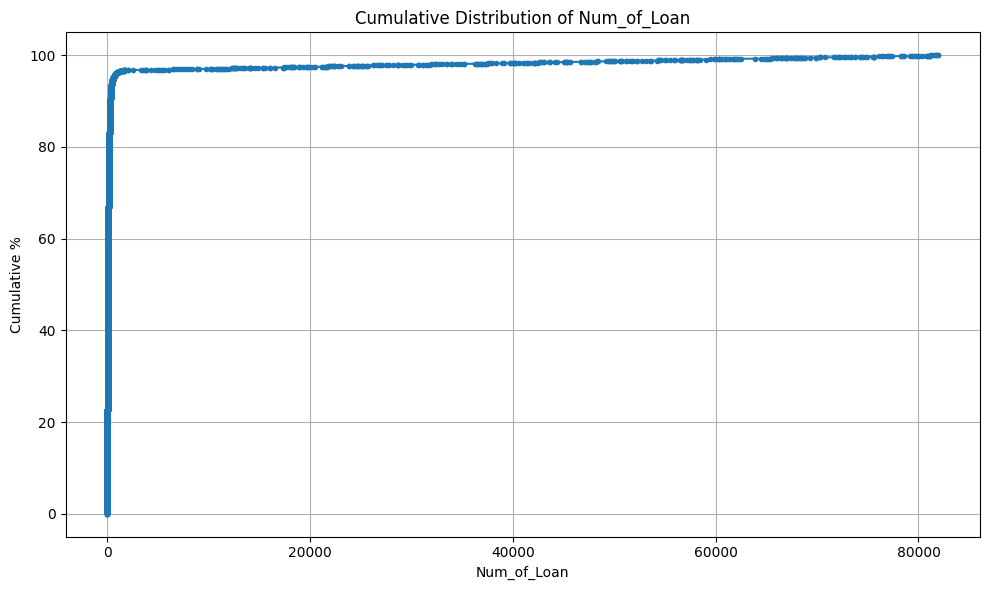

In [185]:
# Convert to pandas
credit_card_pd = df.select("Total_EMI_per_month").toPandas()

# Sort values and calculate cumulative percentage
sorted_vals = np.sort(credit_card_pd["Total_EMI_per_month"])
cumulative = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals) * 100

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sorted_vals, cumulative, marker=".", linestyle="-")
plt.title("Cumulative Distribution of Num_of_Loan")
plt.xlabel("Num_of_Loan")
plt.ylabel("Cumulative %")
plt.grid(True)
plt.tight_layout()
plt.show()

<Axes: >

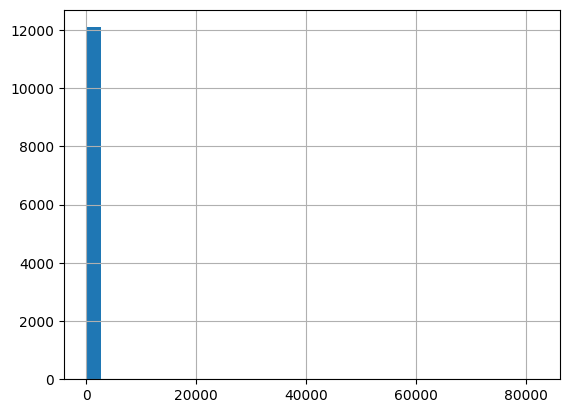

In [180]:
df_pd["Total_EMI_per_month"].describe()
df_pd["Total_EMI_per_month"].value_counts().sort_index()

# Plot to see distribution
df_pd["Total_EMI_per_month"].hist(bins=30)

<Axes: >

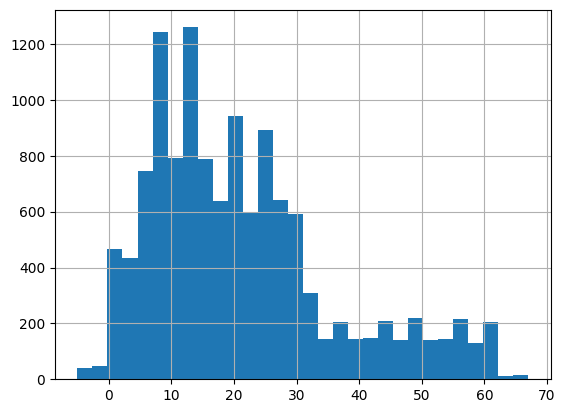

In [179]:
df_pd["Delay_from_due_date"].describe()
df_pd["Delay_from_due_date"].value_counts().sort_index()

# Plot to see distribution
df_pd["Delay_from_due_date"].hist(bins=30)

In [164]:
pd.set_option('display.float_format', '{:.2f}'.format)
df_pd = df.toPandas()
df_pd.describe()

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Years
count,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12246.00,12500.00,12500.00,12500.00,12500.00,11942.00,12499.00,12500.00
mean,161620.56,4188.59,16.94,23.17,73.21,3.10,21.06,33.02,10.40,26.70,1426.22,32.35,1488.39,194.61,403.92,18.72
std,1297841.62,3180.15,114.35,132.01,468.68,65.11,14.86,238.70,6.80,184.19,1155.17,5.16,8561.45,200.63,213.93,8.30
min,7005.93,303.65,-1.00,0.00,1.00,-100.00,-5.00,-3.00,-6.49,0.00,0.23,20.10,0.00,0.00,0.38,0.67
25%,19453.33,1624.94,3.00,4.00,8.00,1.00,10.00,9.00,5.37,4.00,566.07,28.07,31.50,71.36,270.14,12.33
50%,37572.38,3087.59,6.00,5.00,14.00,3.00,18.00,14.00,9.41,6.00,1166.15,32.42,72.89,127.41,339.75,18.50
75%,72690.21,5947.36,7.00,7.00,20.00,5.00,28.00,18.00,14.94,10.00,1945.96,36.62,169.63,234.61,473.38,25.42
max,23834698.00,15204.63,1756.00,1499.00,5789.00,1495.00,67.00,4293.00,36.97,2554.00,4998.07,48.20,81971.00,1977.33,1463.79,33.67


In [71]:
df_pd.describe(include = 'object')

,Customer_ID,Type_of_Loan,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,snapshot_date
count,12500,11074,12500,12500,12500,12500
unique,12500,6260,4,3,7,25
top,CUS_0xffd,Not Specified,Standard,Yes,Low_spent_Small_value_payments,2024-08-01
freq,1,176,4497,6571,3202,543


### Check attr and fin????

### LMS

In [219]:
lms_df = spark.read.csv('data/lms_loan_daily.csv', header = True, inferSchema = True)

In [221]:
df_pd = lms_df.toPandas()

In [223]:
df_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137500 entries, 0 to 137499
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   loan_id          137500 non-null  object 
 1   Customer_ID      137500 non-null  object 
 2   loan_start_date  137500 non-null  object 
 3   tenure           137500 non-null  int32  
 4   installment_num  137500 non-null  int32  
 5   loan_amt         137500 non-null  int32  
 6   due_amt          137500 non-null  float64
 7   paid_amt         137500 non-null  float64
 8   overdue_amt      137500 non-null  float64
 9   balance          137500 non-null  float64
 10  snapshot_date    137500 non-null  object 
dtypes: float64(4), int32(3), object(4)
memory usage: 10.0+ MB


In [225]:
df_pd.describe()

,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance
count,137500.00,137500.00,137500.00,137500.00,137500.00,137500.00,137500.00
mean,10.00,5.00,10000.00,909.09,711.81,871.91,5871.91
std,0.00,3.16,0.00,287.48,485.73,2002.67,3070.78
min,10.00,0.00,10000.00,0.00,0.00,0.00,0.00
25%,10.00,2.00,10000.00,1000.00,0.00,0.00,3000.00
50%,10.00,5.00,10000.00,1000.00,1000.00,0.00,7000.00
75%,10.00,8.00,10000.00,1000.00,1000.00,0.00,8000.00
max,10.00,10.00,10000.00,1000.00,4000.00,10000.00,10000.00


In [227]:
df_pd.describe(include = 'object')

,loan_id,Customer_ID,loan_start_date,snapshot_date
count,137500,137500,137500,137500
unique,12500,12500,25,35
top,CUS_0xffd_2024_03_01,CUS_0xffd,2024-08-01,2025-01-01
freq,11,11,5973,5539
